# ML 입력 데이터 생성 예시

**목적**: 가격 데이터 + 외부지표 + FRED 매크로 + GDELT 감성 데이터를
ML 모델에 투입할 수 있는 `(date, ticker)` 패널 형태로 통합합니다.

**출력**: `ml_panel.csv` — 각 행이 하나의 (날짜, 종목) 관측치이며,
타겟(30일 선행 수익률)과 모든 피처가 포함된 최종 학습 데이터.

---

### 파이프라인 흐름
```
[portfolio_prices.csv] ──→ 수익률 계산 → 종목별 피처(모멘텀, 변동성)
[external_prices.csv ] ──→ VIX, 원자재 등 공통 시장 피처
[fred_data.csv       ] ──→ HY스프레드, 수익률곡선 등 매크로 피처
[GDELT               ] ──→ 종목별 감성 피처 (시뮬레이션 → 실데이터 대체 예정)
         ↓
   (date, ticker) 패널 병합
         ↓
   결측 처리 + 타겟 변수 생성
         ↓
   ml_panel.csv 저장
```

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ─────────────────────────────────────────────────
DATA_DIR = 'Guide/data/'
OUT_DIR  = 'data/'          # 생성 파일 저장 위치

# 30일 선행 수익률을 타겟으로 사용
FORWARD_DAYS = 30

print('설정 완료')

설정 완료


## 1. 원본 데이터 로드

In [2]:
# ── 가격 데이터 (30개 자산) ───────────────────────────────────
prices = pd.read_csv(DATA_DIR + 'portfolio_prices.csv', parse_dates=['Date'], index_col='Date')

# ── 외부 시장 지표 (VIX, 원자재, 크립토, 환율 등) ───────────────
external = pd.read_csv(DATA_DIR + 'external_prices.csv', parse_dates=['Date'], index_col='Date')

# ── FRED 매크로 데이터 ────────────────────────────────────────
fred = pd.read_csv(DATA_DIR + 'fred_data.csv', parse_dates=['Date'], index_col='Date')

# 30개 종목 티커 목록
TICKERS = prices.columns.tolist()

print(f'가격 데이터:  {prices.shape}  ({prices.index[0].date()} ~ {prices.index[-1].date()})')
print(f'외부 지표:    {external.shape}')
print(f'FRED 매크로:  {fred.shape}')
print(f'\n종목 목록({len(TICKERS)}개): {TICKERS}')

가격 데이터:  (2609, 30)  (2016-01-01 ~ 2025-12-31)
외부 지표:    (2609, 12)
FRED 매크로:  (2609, 8)

종목 목록(30개): ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']


## 2. 수익률 계산 및 Long 형태 변환

**Wide → Long 변환**: `(date, ticker)` 멀티인덱스 패널로 변환합니다.
ML 모델에서 각 행이 하나의 (날짜, 종목) 관측치가 됩니다.

In [3]:
# ── 일별 수익률 계산 ──────────────────────────────────────────
daily_ret = prices.pct_change()  # (price_t - price_{t-1}) / price_{t-1}

# ── 30일 선행 수익률 (타겟 변수) ──────────────────────────────
# 오늘 날짜 기준으로 30일 후의 누적 수익률
# shift(-30): 미래 30일 후 값을 현재 행에 붙임
fwd_ret = (1 + daily_ret).rolling(FORWARD_DAYS).apply(np.prod, raw=True).shift(-FORWARD_DAYS) - 1

# ── Wide → Long 변환 ──────────────────────────────────────────
# 수익률 패널: (date, ticker) 인덱스
ret_long = (
    daily_ret
    .stack()                            # Wide → Long
    .reset_index()
    .rename(columns={'level_1': 'ticker', 0: 'ret_1d'})
)

# 타겟(선행 수익률) 추가
fwd_long = (
    fwd_ret
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'ticker', 0: 'fwd_ret_30d'})
)

# 병합
panel = pd.merge(ret_long, fwd_long, on=['Date', 'ticker'], how='left')
panel = panel.rename(columns={'Date': 'date'})

print(f'패널 크기: {panel.shape}')
print(f'행 예시 (date, ticker, 일수익률, 30일선행수익률):')
panel.head(6)

패널 크기: (78240, 4)
행 예시 (date, ticker, 일수익률, 30일선행수익률):


,date,ticker,ret_1d,fwd_ret_30d
0,2016-01-04,SPY,0.0,-0.071585
1,2016-01-04,QQQ,0.0,-0.104840
2,2016-01-04,IWM,0.0,-0.121989
3,2016-01-04,EFA,0.0,-0.095815
4,2016-01-04,EEM,0.0,-0.063558
5,2016-01-04,TLT,0.0,0.084803


## 3. 종목별 피처 생성 (모멘텀, 변동성)

각 종목의 과거 수익률 패턴에서 파생된 피처입니다.
모든 값은 **당일 기준 과거 데이터**만 사용 → look-ahead bias 없음.

In [4]:
# ── 각 종목별 rolling 피처 계산 (Wide 형태에서 계산 후 Long으로 변환) ──

stock_features_wide = pd.DataFrame(index=daily_ret.index)

for ticker in TICKERS:
    r = daily_ret[ticker]

    # 모멘텀: 과거 N일 누적 수익률
    stock_features_wide[f'{ticker}__mom_5d']  = r.rolling(5).sum()
    stock_features_wide[f'{ticker}__mom_20d'] = r.rolling(20).sum()
    stock_features_wide[f'{ticker}__mom_60d'] = r.rolling(60).sum()

    # 변동성: 과거 N일 수익률 표준편차 (연율화)
    stock_features_wide[f'{ticker}__vol_20d'] = r.rolling(20).std() * np.sqrt(252)
    stock_features_wide[f'{ticker}__vol_60d'] = r.rolling(60).std() * np.sqrt(252)

    # 변동성 변화율: 최근 변동성이 과거 대비 얼마나 높아졌는가
    stock_features_wide[f'{ticker}__vol_ratio'] = (
        r.rolling(10).std() / (r.rolling(60).std() + 1e-8)
    )

# Wide → Long 변환 후 패널에 병합
# 컬럼명 형식: 'AAPL__mom_5d' → ticker='AAPL', feature='mom_5d'
stock_feat_long = (
    stock_features_wide
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'ticker_feat', 0: 'value'})
)
stock_feat_long[['ticker', 'feature']] = stock_feat_long['ticker_feat'].str.split('__', expand=True)
stock_feat_long = stock_feat_long.rename(columns={'Date': 'date'})

# 피봇: 각 피처가 컬럼이 되도록
stock_feat_pivot = stock_feat_long.pivot_table(
    index=['date', 'ticker'], columns='feature', values='value'
).reset_index()
stock_feat_pivot.columns.name = None

# 패널에 병합
panel = pd.merge(panel, stock_feat_pivot, on=['date', 'ticker'], how='left')

print(f'종목별 피처 추가 후 패널 크기: {panel.shape}')
print(f'추가된 피처: {[c for c in panel.columns if c not in ["date","ticker","ret_1d","fwd_ret_30d"]]}')

종목별 피처 추가 후 패널 크기: (78240, 10)
추가된 피처: ['mom_20d', 'mom_5d', 'mom_60d', 'vol_20d', 'vol_60d', 'vol_ratio']


## 4. 공통 시장 피처 생성 (VIX, 스프레드, 수익률곡선 등)

모든 종목이 **날짜별로 동일한 값**을 공유하는 매크로/시장 상황 피처입니다.

In [5]:
# ── 외부 시장 지표에서 파생 피처 생성 ────────────────────────
mkt = pd.DataFrame(index=external.index)

# VIX 레벨 및 변화율
mkt['VIX_level']  = external['^VIX']
mkt['VIX_chg_5d'] = external['^VIX'].pct_change(5)   # 5일 변화율

# VIX 텀구조: VIX9D/VIX → 1보다 크면 contango(안정), 작으면 backwardation(불안)
mkt['VIX_contango'] = external['^VIX9D'] / (external['^VIX'] + 1e-8)

# 구리/금 비율: 경기 선행 지표 (높을수록 경기 낙관)
mkt['CuAu_ratio']     = external['HG=F'] / (external['GC=F'] + 1e-8)
mkt['CuAu_ratio_chg'] = mkt['CuAu_ratio'].pct_change(5)

# 원유 가격 변화율
mkt['oil_chg_5d'] = external['CL=F'].pct_change(5)

# 달러 인덱스 변화율
mkt['dollar_chg_5d'] = external['DX-Y.NYB'].pct_change(5)

# ── FRED 매크로 피처 ──────────────────────────────────────────
# HY 스프레드 (신용위험 지표, 높을수록 위험)
mkt['HY_spread']     = fred['BAMLH0A0HYM2']
mkt['HY_spread_chg'] = fred['BAMLH0A0HYM2'].diff(5)   # 5일 변화량

# 수익률곡선: 10년-2년 스프레드 (역전 시 경기침체 신호)
mkt['yield_curve']     = fred['T10Y2Y']
mkt['yield_curve_chg'] = fred['T10Y2Y'].diff(5)

# 10년물 금리 레벨 및 변화
mkt['DGS10']     = fred['DGS10']
mkt['DGS10_chg'] = fred['DGS10'].diff(5)

# 실업 청구건수 (노동시장 신호)
mkt['ICSA_chg'] = fred['ICSA'].pct_change(4)   # 4주 변화율

# (실물경기 트리거는 v5 과제로 보류 — UNRATE z-score, claims_zscore 등 검토)

mkt = mkt.reset_index().rename(columns={'Date': 'date'})

# 패널에 병합 (날짜 기준, 모든 종목에 동일한 값)
panel = pd.merge(panel, mkt, on='date', how='left')

print(f'시장 피처 추가 후 패널 크기: {panel.shape}')
print(f'시장 피처 목록: {mkt.columns[1:].tolist()}')

시장 피처 추가 후 패널 크기: (78240, 25)
시장 피처 목록: ['VIX_level', 'VIX_chg_5d', 'VIX_contango', 'CuAu_ratio', 'CuAu_ratio_chg', 'oil_chg_5d', 'dollar_chg_5d', 'HY_spread', 'HY_spread_chg', 'yield_curve', 'yield_curve_chg', 'DGS10', 'DGS10_chg', 'ICSA_chg', 'SAHM']


## 5. GDELT 감성 피처 생성

### 5-A. 종목별 키워드 매핑 정의

개별 종목은 기업명으로, ETF는 관련 키워드+THEMES로 매핑합니다.
실제 GDELT 수집 후 이 매핑을 사용해 필터링합니다.

In [6]:
# ── 티커 → GDELT 매핑 테이블 ──────────────────────────────────
# type: 'org'     → ORGANIZATIONS 컬럼에서 기업명 직접 검색
#       'keyword' → THEMES + ORGANIZATIONS 조합 키워드 검색

TICKER_TO_GDELT = {

    # ── 개별 대형주: 기업명 직접 매핑 ──────────────────────────
    'AAPL':  {'type': 'org', 'names': ['APPLE INC', 'APPLE COMPUTER']},
    'MSFT':  {'type': 'org', 'names': ['MICROSOFT CORP', 'MICROSOFT CORPORATION']},
    'AMZN':  {'type': 'org', 'names': ['AMAZON.COM INC', 'AMAZON']},
    'GOOGL': {'type': 'org', 'names': ['ALPHABET INC', 'GOOGLE']},
    'JPM':   {'type': 'org', 'names': ['JPMORGAN CHASE', 'JP MORGAN']},
    'JNJ':   {'type': 'org', 'names': ['JOHNSON & JOHNSON', 'JOHNSON AND JOHNSON']},
    'PG':    {'type': 'org', 'names': ['PROCTER & GAMBLE', 'PROCTER AND GAMBLE']},
    'XOM':   {'type': 'org', 'names': ['EXXON MOBIL', 'EXXONMOBIL']},

    # ── 광범위 시장 ETF: 지수명 키워드 ──────────────────────────
    'SPY':   {'type': 'keyword',
              'themes': ['ECON_STOCKMARKET'],
              'keywords': ['S&P 500', 'S&P500', 'STOCK MARKET']},
    'QQQ':   {'type': 'keyword',
              'themes': ['ECON_STOCKMARKET', 'TECHNOLOGY'],
              'keywords': ['NASDAQ', 'TECH STOCKS', 'TECHNOLOGY SECTOR']},
    'IWM':   {'type': 'keyword',
              'themes': ['ECON_STOCKMARKET'],
              'keywords': ['RUSSELL 2000', 'SMALL CAP', 'SMALL-CAP']},
    'EFA':   {'type': 'keyword',
              'themes': ['ECON_STOCKMARKET'],
              'keywords': ['MSCI EAFE', 'DEVELOPED MARKET', 'INTERNATIONAL EQUITY']},
    'EEM':   {'type': 'keyword',
              'themes': ['ECON_STOCKMARKET'],
              'keywords': ['MSCI EMERGING', 'EMERGING MARKET', 'EM EQUITY']},

    # ── 섹터 ETF: 섹터 키워드 ────────────────────────────────────
    'XLK':   {'type': 'keyword',
              'themes': ['TECHNOLOGY'],
              'keywords': ['TECHNOLOGY SECTOR', 'TECH SECTOR', 'INFORMATION TECHNOLOGY']},
    'XLF':   {'type': 'keyword',
              'themes': ['ECON_BANKRUPTCY', 'ECON_STOCKMARKET'],
              'keywords': ['FINANCIAL SECTOR', 'BANKING SECTOR', 'FINANCIAL STOCKS']},
    'XLE':   {'type': 'keyword',
              'themes': ['ENV_OIL', 'ENERGY'],
              'keywords': ['ENERGY SECTOR', 'OIL STOCKS', 'ENERGY STOCKS']},
    'XLV':   {'type': 'keyword',
              'themes': ['HEALTH'],
              'keywords': ['HEALTH CARE SECTOR', 'HEALTHCARE STOCKS', 'PHARMA SECTOR']},
    'VOX':   {'type': 'keyword',
              'themes': ['TECHNOLOGY'],
              'keywords': ['COMMUNICATION SERVICES', 'TELECOM SECTOR']},
    'XLY':   {'type': 'keyword',
              'themes': ['ECON_RETAIL'],
              'keywords': ['CONSUMER DISCRETIONARY', 'CONSUMER SPENDING', 'RETAIL SECTOR']},
    'XLP':   {'type': 'keyword',
              'themes': ['ECON_RETAIL'],
              'keywords': ['CONSUMER STAPLES', 'DEFENSIVE STOCKS', 'STAPLES SECTOR']},
    'XLI':   {'type': 'keyword',
              'themes': ['ECON_TRADE'],
              'keywords': ['INDUSTRIAL SECTOR', 'INDUSTRIALS', 'MANUFACTURING SECTOR']},
    'XLU':   {'type': 'keyword',
              'themes': ['ENERGY'],
              'keywords': ['UTILITIES SECTOR', 'ELECTRIC UTILITIES', 'UTILITY STOCKS']},
    'XLRE':  {'type': 'keyword',
              'themes': ['ECON_REALESTATE'],
              'keywords': ['REAL ESTATE SECTOR', 'REIT SECTOR', 'PROPERTY SECTOR']},
    'XLB':   {'type': 'keyword',
              'themes': ['COMMODITY'],
              'keywords': ['MATERIALS SECTOR', 'BASIC MATERIALS', 'CHEMICALS SECTOR']},

    # ── 채권 ETF: 금리 키워드 ─────────────────────────────────────
    'TLT':   {'type': 'keyword',
              'themes': ['ECON_INTEREST_RATES'],
              'keywords': ['20-YEAR TREASURY', '30-YEAR BOND', 'LONG-TERM TREASURY']},
    'AGG':   {'type': 'keyword',
              'themes': ['ECON_INTEREST_RATES'],
              'keywords': ['INVESTMENT GRADE', 'BOND MARKET', 'AGGREGATE BOND']},
    'SHY':   {'type': 'keyword',
              'themes': ['ECON_INTEREST_RATES'],
              'keywords': ['2-YEAR TREASURY', 'SHORT-TERM TREASURY', 'FED FUNDS RATE']},
    'TIP':   {'type': 'keyword',
              'themes': ['ECON_INTEREST_RATES', 'ECON_INFLATION'],
              'keywords': ['TIPS', 'INFLATION PROTECTED', 'REAL YIELD']},

    # ── 대안 ETF: 자산클래스 키워드 ──────────────────────────────
    'GLD':   {'type': 'keyword',
              'themes': ['ECON_GOLD', 'COMMODITY'],
              'keywords': ['GOLD PRICE', 'PRECIOUS METALS', 'GOLD MARKET']},
    'DBC':   {'type': 'keyword',
              'themes': ['COMMODITY'],
              'keywords': ['COMMODITY INDEX', 'RAW MATERIALS', 'COMMODITY MARKET']},
}

print(f'매핑 정의된 종목 수: {len(TICKER_TO_GDELT)}')
print(f'전체 종목 수:         {len(TICKERS)}')

# 매핑 유형별 분류 확인
org_type     = [t for t,v in TICKER_TO_GDELT.items() if v['type'] == 'org']
keyword_type = [t for t,v in TICKER_TO_GDELT.items() if v['type'] == 'keyword']
print(f'\n기업명 직접 매핑: {org_type}')
print(f'키워드 매핑:      {keyword_type}')

매핑 정의된 종목 수: 30
전체 종목 수:         30

기업명 직접 매핑: ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
키워드 매핑:      ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB', 'TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC']


### 5-B. GDELT 필터링 함수

실제 GDELT GKG 파일이 수집된 경우 아래 함수를 사용합니다.

In [7]:
def extract_gdelt_for_ticker(gkg: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """
    GDELT GKG 테이블에서 특정 티커에 해당하는 행을 추출합니다.

    Parameters
    ----------
    gkg    : GDELT GKG 원본 DataFrame (DATE, THEMES, ORGANIZATIONS, V2Tone 컬럼 필수)
    ticker : 추출할 종목 티커

    Returns
    -------
    ticker 컬럼이 추가된 필터링 결과 DataFrame
    """
    if ticker not in TICKER_TO_GDELT:
        return pd.DataFrame()   # 매핑 없으면 빈 DataFrame 반환

    config = TICKER_TO_GDELT[ticker]

    if config['type'] == 'org':
        # 기업명 직접 매칭: ORGANIZATIONS 컬럼에 기업명이 포함된 행 추출
        pattern = '|'.join(config['names'])
        mask = gkg['ORGANIZATIONS'].str.contains(pattern, na=False, case=False)

    elif config['type'] == 'keyword':
        # THEMES 1차 필터 (대분류)
        theme_pattern = '|'.join(config['themes'])
        mask_theme = gkg['THEMES'].str.contains(theme_pattern, na=False, case=False)

        # 키워드 2차 필터 (세부 키워드, 노이즈 감소 목적)
        kw_pattern = '|'.join(config['keywords'])
        mask_kw = (
            gkg['ORGANIZATIONS'].str.contains(kw_pattern, na=False, case=False) |
            gkg['THEMES'].str.contains(kw_pattern, na=False, case=False)
        )

        mask = mask_theme & mask_kw

    matched = gkg[mask].copy()
    matched['ticker'] = ticker
    return matched


def aggregate_gdelt_by_stock(gkg: pd.DataFrame) -> pd.DataFrame:
    """
    전체 GKG 데이터를 (date, ticker) 기준으로 집계합니다.

    Returns
    -------
    (date, ticker) 인덱스의 집계 DataFrame
    컬럼: tone_avg, tone_neg, tone_polar, event_count, tone_std
    """
    # V2Tone 파싱: '전체,긍정,부정,양극화,...' 형식의 문자열을 숫자로 분리
    tone_split = gkg['V2Tone'].str.split(',', expand=True)
    gkg = gkg.copy()
    gkg['tone_avg']   = pd.to_numeric(tone_split[0], errors='coerce')  # 전체 감성
    gkg['tone_pos']   = pd.to_numeric(tone_split[1], errors='coerce')  # 긍정
    gkg['tone_neg']   = pd.to_numeric(tone_split[2], errors='coerce')  # 부정
    gkg['tone_polar'] = pd.to_numeric(tone_split[3], errors='coerce')  # 양극화

    # DATE 컬럼을 날짜 형식으로 변환 (GDELT 형식: YYYYMMDDHHMMSS)
    gkg['date'] = pd.to_datetime(gkg['DATE'].astype(str).str[:8], format='%Y%m%d')

    # 종목별로 필터링 후 합치기
    all_rows = []
    for ticker in TICKERS:
        matched = extract_gdelt_for_ticker(gkg, ticker)
        if not matched.empty:
            all_rows.append(matched)

    if not all_rows:
        return pd.DataFrame()

    gdelt_mapped = pd.concat(all_rows, ignore_index=True)

    # (date, ticker) 기준 일별 집계
    result = (
        gdelt_mapped
        .groupby(['date', 'ticker'])
        .agg(
            gdelt_tone_avg   = ('tone_avg',   'mean'),   # 평균 감성
            gdelt_tone_neg   = ('tone_neg',   'mean'),   # 평균 부정 감성
            gdelt_tone_polar = ('tone_polar', 'mean'),   # 평균 양극화
            gdelt_event_cnt  = ('tone_avg',   'count'),  # 기사 등장 횟수
            gdelt_tone_std   = ('tone_avg',   'std'),    # 감성 변동성
        )
        .reset_index()
    )
    return result


# ── 실제 사용법 (GDELT 파일이 있을 때) ───────────────────────
# gkg_raw = pd.read_csv('gdelt_gkg_collected.csv')
# gdelt_features = aggregate_gdelt_by_stock(gkg_raw)

print('GDELT 처리 함수 정의 완료')

GDELT 처리 함수 정의 완료


### 5-C. GDELT 시뮬레이션 (실 데이터 수집 전 테스트용)

실제 GDELT 수집이 완료되기 전까지, 구조 검증을 위한 시뮬레이션 데이터를 사용합니다.

> **주의**: 아래 시뮬레이션 블록은 실제 GDELT 수집 완료 후 `aggregate_gdelt_by_stock()` 호출로 대체합니다.

In [8]:
np.random.seed(42)

# 날짜 범위
dates = prices.index

# ── 종목별 커버리지 현실 반영 ─────────────────────────────────
# 실제 GDELT에서 기대되는 커버리지 비율 (0 = 해당 날짜에 기사 없음)
COVERAGE_RATE = {
    # 개별 대형주: 높은 커버리지
    'AAPL': 0.90, 'MSFT': 0.88, 'AMZN': 0.87, 'GOOGL': 0.85,
    'JPM':  0.82, 'JNJ':  0.78, 'PG':   0.75, 'XOM':   0.80,
    # 광범위 ETF: 중간
    'SPY': 0.70, 'QQQ': 0.65, 'IWM': 0.55, 'EFA': 0.50, 'EEM': 0.55,
    # 섹터 ETF: 중간
    'XLK': 0.60, 'XLF': 0.58, 'XLE': 0.62, 'XLV': 0.55,
    'VOX': 0.50, 'XLY': 0.52, 'XLP': 0.48, 'XLI': 0.50,
    'XLU': 0.45, 'XLRE': 0.55, 'XLB': 0.48,
    # 채권 ETF: 키워드 매핑으로 개선된 커버리지
    'TLT': 0.75, 'AGG': 0.65, 'SHY': 0.70, 'TIP': 0.68,
    # 대안 ETF
    'GLD': 0.70, 'DBC': 0.60,
}

sim_rows = []
for ticker in TICKERS:
    cov = COVERAGE_RATE.get(ticker, 0.5)
    n   = len(dates)

    # 기사가 있는 날(커버리지) vs 없는 날(NaN)
    has_article = np.random.random(n) < cov

    tone_avg   = np.where(has_article, np.random.normal(1.5, 2.0, n), np.nan)
    tone_neg   = np.where(has_article, np.random.normal(-1.2, 0.8, n), np.nan)
    tone_polar = np.where(has_article, np.abs(np.random.normal(3.5, 1.5, n)), np.nan)
    event_cnt  = np.where(has_article, np.random.poisson(20 * cov, n), 0).astype(float)
    tone_std   = np.where(has_article, np.abs(np.random.normal(1.5, 0.5, n)), np.nan)

    df = pd.DataFrame({
        'date':             dates,
        'ticker':           ticker,
        'gdelt_tone_avg':   tone_avg,
        'gdelt_tone_neg':   tone_neg,
        'gdelt_tone_polar': tone_polar,
        'gdelt_event_cnt':  event_cnt,
        'gdelt_tone_std':   tone_std,
    })
    sim_rows.append(df)

gdelt_sim = pd.concat(sim_rows, ignore_index=True)

print(f'시뮬레이션 GDELT 크기: {gdelt_sim.shape}')
print('\n종목별 GDELT 커버리지 (기사 있는 날 비율):')
coverage_check = gdelt_sim.groupby('ticker')['gdelt_tone_avg'].apply(lambda x: x.notna().mean())
print(coverage_check.round(2).to_string())

시뮬레이션 GDELT 크기: (78270, 7)

종목별 GDELT 커버리지 (기사 있는 날 비율):
ticker
AAPL     0.89
AGG      0.65
AMZN     0.88
DBC      0.59
EEM      0.55
EFA      0.49
GLD      0.71
GOOGL    0.84
IWM      0.54
JNJ      0.77
JPM      0.83
MSFT     0.89
PG       0.77
QQQ      0.66
SHY      0.69
SPY      0.70
TIP      0.67
TLT      0.75
VOX      0.49
XLB      0.48
XLE      0.61
XLF      0.56
XLI      0.52
XLK      0.61
XLP      0.48
XLRE     0.53
XLU      0.45
XLV      0.56
XLY      0.52
XOM      0.80


## 6. 최종 패널 병합 및 결측 처리

In [9]:
# ── GDELT 병합 ─────────────────────────────────────────────────
# 실제 수집 시: gdelt_sim → aggregate_gdelt_by_stock(gkg_raw)
panel = pd.merge(panel, gdelt_sim, on=['date', 'ticker'], how='left')

print(f'최종 패널 크기: {panel.shape}')
print(f'컬럼 목록:\n{panel.columns.tolist()}')

최종 패널 크기: (78240, 30)
컬럼 목록:
['date', 'ticker', 'ret_1d', 'fwd_ret_30d', 'mom_20d', 'mom_5d', 'mom_60d', 'vol_20d', 'vol_60d', 'vol_ratio', 'VIX_level', 'VIX_chg_5d', 'VIX_contango', 'CuAu_ratio', 'CuAu_ratio_chg', 'oil_chg_5d', 'dollar_chg_5d', 'HY_spread', 'HY_spread_chg', 'yield_curve', 'yield_curve_chg', 'DGS10', 'DGS10_chg', 'ICSA_chg', 'SAHM', 'gdelt_tone_avg', 'gdelt_tone_neg', 'gdelt_tone_polar', 'gdelt_event_cnt', 'gdelt_tone_std']


In [10]:
# ── 결측 처리 ─────────────────────────────────────────────────
# 전략: 0 채움 + 결측 플래그 컬럼 추가
# 이유: 모델이 'GDELT 신호 없음'을 별도의 상태로 학습할 수 있게 함

gdelt_cols = ['gdelt_tone_avg', 'gdelt_tone_neg', 'gdelt_tone_polar',
              'gdelt_event_cnt', 'gdelt_tone_std']

# GDELT 데이터 존재 여부 플래그 (1: 기사 있음, 0: 없음)
panel['gdelt_has_data'] = panel['gdelt_tone_avg'].notna().astype(int)

# 결측값을 0으로 채움 (기사 없음 = 중립 신호로 해석)
for col in gdelt_cols:
    panel[col] = panel[col].fillna(0)

# 수익률 기반 피처의 초기 NaN (rolling window 준비 기간)
# → 학습 시 dropna로 처리 (타겟 없는 행도 제거)

# 타겟 없는 행 제거 (예측 불가한 마지막 30일)
panel_clean = panel.dropna(subset=['fwd_ret_30d'])

print(f'결측 처리 전: {panel.shape[0]:,}행')
print(f'결측 처리 후: {panel_clean.shape[0]:,}행')
print(f'\n컬럼별 결측 비율 (%):')
missing = (panel_clean.isnull().sum() / len(panel_clean) * 100).round(1)
print(missing[missing > 0].to_string() if missing[missing > 0].any() else '결측 없음')

결측 처리 전: 78,240행
결측 처리 후: 77,340행

컬럼별 결측 비율 (%):
mom_20d            0.7
mom_5d             0.2
mom_60d            2.3
vol_20d            0.7
vol_60d            2.3
vol_ratio          2.3
VIX_chg_5d         0.2
CuAu_ratio_chg     0.2
oil_chg_5d         0.2
dollar_chg_5d      0.2
HY_spread_chg      0.2
yield_curve_chg    0.2
DGS10_chg          0.2
ICSA_chg           0.1


## 7. Walk-Forward 분할 예시

**IS 150일 × 30종목 = 4,500행** 학습 → **OOS 30일 × 30종목 = 900행** 예측

In [11]:
IS_DAYS  = 150   # 학습 창 크기 (거래일)
OOS_DAYS = 30    # 예측 창 크기 (거래일)

# 날짜 기준 Walk-Forward 윈도우 생성
unique_dates = sorted(panel_clean['date'].unique())

windows = []
i = 0
while i + IS_DAYS + OOS_DAYS <= len(unique_dates):
    is_start  = unique_dates[i]
    is_end    = unique_dates[i + IS_DAYS - 1]
    oos_start = unique_dates[i + IS_DAYS]
    oos_end   = unique_dates[i + IS_DAYS + OOS_DAYS - 1]
    windows.append({
        'window':    len(windows) + 1,
        'is_start':  is_start,
        'is_end':    is_end,
        'oos_start': oos_start,
        'oos_end':   oos_end,
    })
    i += OOS_DAYS   # OOS 크기만큼 슬라이딩

windows_df = pd.DataFrame(windows)
print(f'총 Walk-Forward 윈도우 수: {len(windows_df)}')
print(f'\n처음 3개 / 마지막 3개 윈도우:')
print(pd.concat([windows_df.head(3), windows_df.tail(3)]).to_string(index=False))

총 Walk-Forward 윈도우 수: 80

처음 3개 / 마지막 3개 윈도우:
 window   is_start     is_end  oos_start    oos_end
      1 2016-01-04 2016-07-29 2016-08-01 2016-09-09
      2 2016-02-15 2016-09-09 2016-09-12 2016-10-21
      3 2016-03-28 2016-10-21 2016-10-24 2016-12-02
     78 2024-11-11 2025-06-06 2025-06-09 2025-07-18
     79 2024-12-23 2025-07-18 2025-07-21 2025-08-29
     80 2025-02-03 2025-08-29 2025-09-01 2025-10-10


In [12]:
# ── 첫 번째 윈도우 데이터 추출 예시 ──────────────────────────

# 피처 컬럼 목록 (타겟·날짜·식별자 제외)
TARGET_COL = 'fwd_ret_30d'
ID_COLS    = ['date', 'ticker', 'ret_1d']   # 학습에 사용하지 않는 컬럼
FEAT_COLS  = [c for c in panel_clean.columns if c not in ID_COLS + [TARGET_COL]]

# 첫 번째 윈도우
w = windows[0]

is_mask  = (panel_clean['date'] >= w['is_start'])  & (panel_clean['date'] <= w['is_end'])
oos_mask = (panel_clean['date'] >= w['oos_start']) & (panel_clean['date'] <= w['oos_end'])

X_train = panel_clean.loc[is_mask,  FEAT_COLS]
y_train = panel_clean.loc[is_mask,  TARGET_COL]

X_test  = panel_clean.loc[oos_mask, FEAT_COLS]
y_test  = panel_clean.loc[oos_mask, TARGET_COL]

print('=== 첫 번째 Walk-Forward 윈도우 ===')
print(f'IS  기간: {w["is_start"]} ~ {w["is_end"]}')
print(f'OOS 기간: {w["oos_start"]} ~ {w["oos_end"]}')
print(f'\n학습 데이터 (X_train): {X_train.shape}  ← {IS_DAYS}일 × {len(TICKERS)}종목')
print(f'예측 데이터 (X_test):  {X_test.shape}   ← {OOS_DAYS}일 × {len(TICKERS)}종목')
print(f'피처 수: {len(FEAT_COLS)}개')
print(f'\n피처 목록:\n{FEAT_COLS}')

=== 첫 번째 Walk-Forward 윈도우 ===
IS  기간: 2016-01-04 00:00:00 ~ 2016-07-29 00:00:00
OOS 기간: 2016-08-01 00:00:00 ~ 2016-09-09 00:00:00

학습 데이터 (X_train): (4500, 27)  ← 150일 × 30종목
예측 데이터 (X_test):  (900, 27)   ← 30일 × 30종목
피처 수: 27개

피처 목록:
['mom_20d', 'mom_5d', 'mom_60d', 'vol_20d', 'vol_60d', 'vol_ratio', 'VIX_level', 'VIX_chg_5d', 'VIX_contango', 'CuAu_ratio', 'CuAu_ratio_chg', 'oil_chg_5d', 'dollar_chg_5d', 'HY_spread', 'HY_spread_chg', 'yield_curve', 'yield_curve_chg', 'DGS10', 'DGS10_chg', 'ICSA_chg', 'SAHM', 'gdelt_tone_avg', 'gdelt_tone_neg', 'gdelt_tone_polar', 'gdelt_event_cnt', 'gdelt_tone_std', 'gdelt_has_data']


## 8. Q 벡터 추출 예시 (ML → Black-Litterman)

OOS 첫날 30개 종목의 예측값 → Black-Litterman Q 벡터

In [13]:
from sklearn.ensemble import RandomForestRegressor

# ── 간단한 RF 학습 예시 ──────────────────────────────────────
X_train_filled = X_train.fillna(0)   # rolling 초기 NaN 처리
X_test_filled  = X_test.fillna(0)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_filled, y_train)

# ── OOS 첫날 30개 종목 예측 → Q 벡터 ─────────────────────────
# OOS 첫날 날짜 기준, 각 종목 1행씩 추출
oos_first_day = w['oos_start']
X_first_day   = panel_clean.loc[
    panel_clean['date'] == oos_first_day, ['ticker'] + FEAT_COLS
].set_index('ticker')

# TICKERS 순서에 맞게 정렬 (BL에서 순서 일치 중요)
X_first_day = X_first_day.reindex(TICKERS).fillna(0)

# RF 예측: 각 트리의 예측을 모아 Q(평균)와 Ω 대각(표준편차²) 산출
tree_preds = np.array([tree.predict(X_first_day) for tree in rf.estimators_])
# tree_preds shape: (n_trees, 30)

Q_vector = tree_preds.mean(axis=0)    # 각 종목의 예측 평균 → Q (30,)
Q_sigma  = tree_preds.std(axis=0)     # 각 종목의 예측 표준편차 → Ω 대각 원소 (30,)
Omega    = np.diag(Q_sigma ** 2)      # Ω = 대각 공분산 행렬 (30×30)

# 결과 확인
q_df = pd.DataFrame({
    'ticker': TICKERS,
    'Q (예측 수익률)': Q_vector.round(4),
    'Q_std (불확실성)': Q_sigma.round(4),
}).set_index('ticker')

print(f'=== Q 벡터 ({oos_first_day} 기준) ===')
print(q_df.to_string())
print(f'\nΩ 행렬 크기: {Omega.shape}  (대각 행렬)')

=== Q 벡터 (2016-08-01 00:00:00 기준) ===
        Q (예측 수익률)  Q_std (불확실성)
ticker                          
SPY         0.0037        0.0244
QQQ         0.0040        0.0269
IWM         0.0073        0.0298
EFA         0.0118        0.0300
EEM         0.0155        0.0264
TLT        -0.0150        0.0358
AGG         0.0026        0.0062
SHY        -0.0003        0.0163
TIP         0.0025        0.0101
GLD        -0.0007        0.0427
DBC         0.0383        0.0332
XLK        -0.0104        0.0322
XLF         0.0145        0.0245
XLE         0.0315        0.0394
XLV        -0.0307        0.0248
VOX        -0.0298        0.0344
XLY         0.0017        0.0286
XLP         0.0115        0.0326
XLI        -0.0003        0.0213
XLU        -0.0186        0.0383
XLRE       -0.0097        0.0275
XLB         0.0053        0.0340
AAPL        0.0192        0.0285
MSFT        0.0206        0.0246
AMZN       -0.0017        0.0375
GOOGL      -0.0132        0.0478
JPM         0.0241        0.0306
JNJ  

## 9. 최종 데이터 저장 및 요약

In [14]:
import os
os.makedirs(OUT_DIR, exist_ok=True)

# 최종 패널 저장
out_path = OUT_DIR + 'ml_panel.csv'
panel_clean.to_csv(out_path, index=False, encoding='utf-8-sig')

print('=== 최종 ML 패널 요약 ===')
print(f'저장 경로:   {out_path}')
print(f'크기:        {panel_clean.shape}  ({panel_clean.shape[0]:,}행 × {panel_clean.shape[1]}열)')
print(f'기간:        {panel_clean["date"].min()} ~ {panel_clean["date"].max()}')
print(f'종목 수:     {panel_clean["ticker"].nunique()}개')
print(f'\n피처 구성:')
print(f'  - 종목별 기술 피처 (모멘텀/변동성): {len([c for c in FEAT_COLS if any(k in c for k in ["mom","vol_"])])}개')
print(f'  - 공통 시장 피처 (VIX/스프레드 등): {len([c for c in FEAT_COLS if c in mkt.columns[1:].tolist()])}개')
print(f'  - GDELT 감성 피처:                  {len([c for c in FEAT_COLS if "gdelt" in c])}개')
print(f'  - 합계:                             {len(FEAT_COLS)}개')

=== 최종 ML 패널 요약 ===
저장 경로:   data/ml_panel.csv
크기:        (77340, 31)  (77,340행 × 31열)
기간:        2016-01-04 00:00:00 ~ 2025-11-19 00:00:00
종목 수:     30개

피처 구성:
  - 종목별 기술 피처 (모멘텀/변동성): 6개
  - 공통 시장 피처 (VIX/스프레드 등): 15개
  - GDELT 감성 피처:                  6개
  - 합계:                             27개


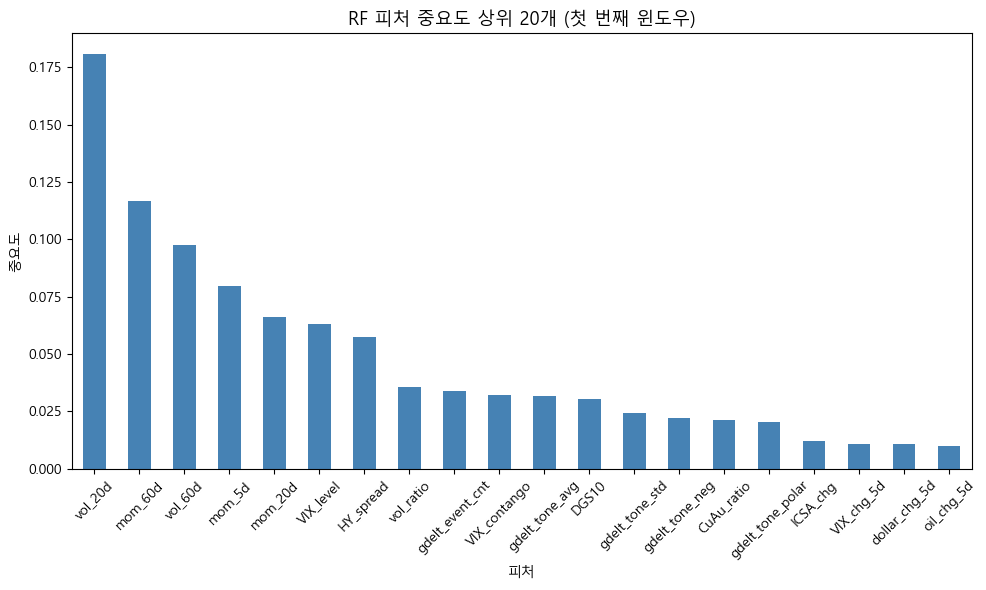

피처 중요도 그래프 저장 완료


In [15]:
# ── 피처 중요도 시각화 (RF 기준) ─────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEAT_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('RF 피처 중요도 상위 20개 (첫 번째 윈도우)', fontsize=13)
ax.set_xlabel('피처')
ax.set_ylabel('중요도')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR + 'feature_importance_w1.png', dpi=120)
plt.show()
print('피처 중요도 그래프 저장 완료')

In [16]:
# ══════════════════════════════════════════════════════════════
# Ablation Study: GDELT 피처 유무에 따른 모델 성능 비교
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# GDELT 관련 피처 컬럼 목록
GDELT_COLS = ['gdelt_tone_avg', 'gdelt_tone_neg', 'gdelt_tone_polar',
              'gdelt_event_cnt', 'gdelt_tone_std', 'gdelt_has_data']

# 피처 세트 정의
FEAT_COLS_full    = FEAT_COLS                                         # GDELT 포함
FEAT_COLS_no_gdelt = [c for c in FEAT_COLS if c not in GDELT_COLS]   # GDELT 제외

print(f"전체 피처 수:          {len(FEAT_COLS_full)}개")
print(f"GDELT 제외 피처 수:    {len(FEAT_COLS_no_gdelt)}개")
print(f"제거된 GDELT 피처:     {[c for c in FEAT_COLS_full if c not in FEAT_COLS_no_gdelt]}")

def run_walk_forward_ablation(panel_clean, windows, feat_cols, model_name='model'):
    """
    Walk-Forward 전체 윈도우에 걸쳐 RF를 학습·예측하고 성능 지표를 반환합니다.

    Parameters
    ----------
    panel_clean : 최종 ML 패널 DataFrame
    windows     : walk-forward 윈도우 리스트 (is_start, is_end, oos_start, oos_end)
    feat_cols   : 사용할 피처 컬럼 리스트
    model_name  : 결과 DataFrame에 표시할 모델 이름

    Returns
    -------
    결과 DataFrame: 윈도우별 RMSE, IC(Spearman), R²
    """
    results = []

    for idx, w in enumerate(windows):
        # ── 학습/예측 데이터 분리 ─────────────────────────────────
        is_mask  = (panel_clean['date'] >= w['is_start']) & (panel_clean['date'] <= w['is_end'])
        oos_mask = (panel_clean['date'] >= w['oos_start']) & (panel_clean['date'] <= w['oos_end'])

        X_train = panel_clean.loc[is_mask,  feat_cols].fillna(0)
        y_train = panel_clean.loc[is_mask,  TARGET_COL]
        X_test  = panel_clean.loc[oos_mask, feat_cols].fillna(0)
        y_test  = panel_clean.loc[oos_mask, TARGET_COL]

        # ── 타겟 결측 제거 ────────────────────────────────────────
        valid_train = y_train.notna()
        valid_test  = y_test.notna()
        X_train, y_train = X_train[valid_train], y_train[valid_train]
        X_test,  y_test  = X_test[valid_test],  y_test[valid_test]

        if len(y_test) == 0:
            continue

        # ── RF 학습·예측 ──────────────────────────────────────────
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        # ── 성능 지표 계산 ────────────────────────────────────────
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        ic, _ = spearmanr(y_test, y_pred)       # IC: 예측 순위 상관계수 (알파 신호 품질)
        r2 = rf.score(X_test, y_test)

        results.append({
            'window':    idx + 1,
            'oos_start': w['oos_start'],
            'model':     model_name,
            'RMSE':      rmse,
            'IC':        ic,
            'R2':        r2,
        })

    return pd.DataFrame(results)


전체 피처 수:          27개
GDELT 제외 피처 수:    21개
제거된 GDELT 피처:     ['gdelt_tone_avg', 'gdelt_tone_neg', 'gdelt_tone_polar', 'gdelt_event_cnt', 'gdelt_tone_std', 'gdelt_has_data']


In [17]:
print("▶ [1/2] GDELT 포함 모델 학습 중…")
res_full     = run_walk_forward_ablation(panel_clean, windows, FEAT_COLS_full,     'With GDELT')

print("▶ [2/2] GDELT 제외 모델 학습 중…")
res_no_gdelt = run_walk_forward_ablation(panel_clean, windows, FEAT_COLS_no_gdelt, 'Without GDELT')

# 결과 합치기
ablation_df = pd.concat([res_full, res_no_gdelt], ignore_index=True)

# 집계 요약
summary = ablation_df.groupby('model')[['RMSE', 'IC', 'R2']].agg(['mean', 'std']).round(4)
print("\n=== Ablation 요약 ===")
print(summary)


▶ [1/2] GDELT 포함 모델 학습 중…
▶ [2/2] GDELT 제외 모델 학습 중…

=== Ablation 요약 ===
                 RMSE              IC              R2        
                 mean     std    mean     std    mean     std
model                                                        
With GDELT     0.0664  0.0319  0.1546  0.1886 -0.5475  0.7479
Without GDELT  0.0666  0.0320  0.1527  0.1853 -0.5570  0.7604


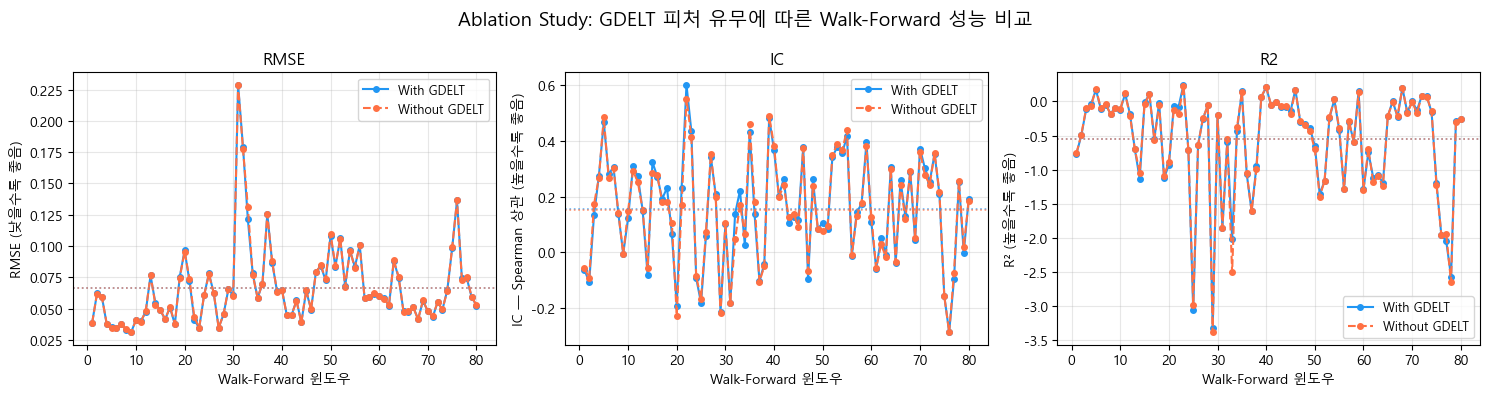

In [18]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

metrics   = ['RMSE', 'IC', 'R2']
ylabels   = ['RMSE (낮을수록 좋음)', 'IC — Spearman 상관 (높을수록 좋음)', 'R² (높을수록 좋음)']
colors    = {'With GDELT': '#2196F3', 'Without GDELT': '#FF7043'}
linestyle = {'With GDELT': '-',       'Without GDELT': '--'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Ablation Study: GDELT 피처 유무에 따른 Walk-Forward 성능 비교', fontsize=14)

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    for model_name, grp in ablation_df.groupby('model'):
        ax.plot(grp['window'], grp[metric],
                label=model_name,
                color=colors[model_name],
                linestyle=linestyle[model_name],
                marker='o', markersize=4)

    # 윈도우 평균 수평선
    for model_name, grp in ablation_df.groupby('model'):
        ax.axhline(grp[metric].mean(),
                   color=colors[model_name], linestyle=':', linewidth=1.2, alpha=0.7)

    ax.set_title(metric)
    ax.set_xlabel('Walk-Forward 윈도우')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_gdelt.png', dpi=150, bbox_inches='tight')
plt.show()


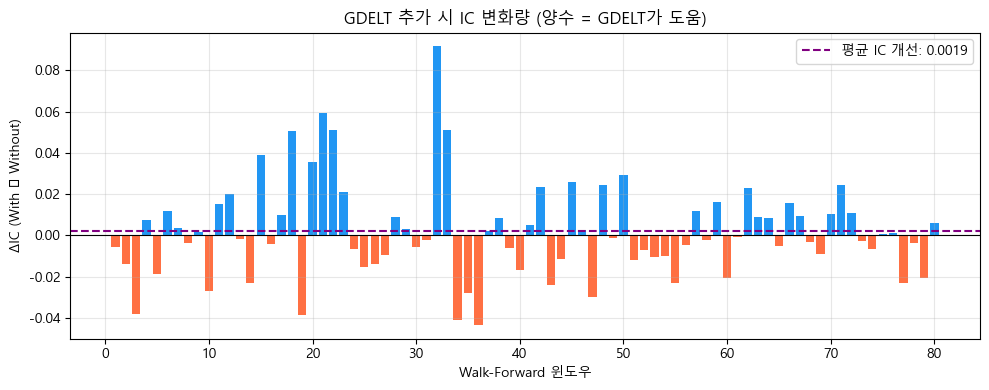


GDELT 포함 시 IC가 향상된 윈도우: 38 / 80개
평균 ΔIC: 0.0019


In [19]:
# GDELT가 실제로 IC를 얼마나 개선/악화시켰는지 윈도우별로 확인
ic_diff = (res_full.set_index('window')['IC']
           - res_no_gdelt.set_index('window')['IC'])

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ['#2196F3' if v >= 0 else '#FF7043' for v in ic_diff]
ax.bar(ic_diff.index, ic_diff.values, color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(ic_diff.mean(), color='purple', linestyle='--',
           label=f'평균 IC 개선: {ic_diff.mean():.4f}')
ax.set_title('GDELT 추가 시 IC 변화량 (양수 = GDELT가 도움)')
ax.set_xlabel('Walk-Forward 윈도우')
ax.set_ylabel('ΔIC (With − Without)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_ic_diff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGDELT 포함 시 IC가 향상된 윈도우: {(ic_diff > 0).sum()} / {len(ic_diff)}개")
print(f"평균 ΔIC: {ic_diff.mean():.4f}")
